In [12]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

# Introduction

### Column Definitions

| Column Name             | Description |
|-------------------------|-------------|
| **ADDRESS** | The civic or street address associated with the property. Used for identification, validation, and potential geocoding. |
| **ASSESSED_VALUE** | The official monetary value assigned to the property by the municipal assessor, typically for taxation purposes. This value reflects an estimated market value at a specific assessment date and may differ from actual sale prices. |
| **COMM_CODE** | A categorical or numerical code representing the commercial classification of the property. Used by municipalities to group properties by use type (e.g., retail, office, industrial). |
| **YEAR_OF_CONSTRUCTION** | The year in which the property was originally built. Useful for analyzing property age, depreciation, and development trends. |
| **LAND_USE_DESIGNATION** | The official zoning or land-use classification assigned by the city or planning authority, defining legally permitted activities on the land. |
| **LAND_SIZE_SM** | The total land area of the property measured in square meters. Important for density analysis, valuation per unit area, and zoning studies. |
| **SUB_PROPERTY_USE** | A detailed descriptor of how the property is actually used within its broader land-use category (e.g., restaurant, office, warehouse, mixed-use). |
| **LATITUDE** | The geographic latitude coordinate of the property location, used for spatial analysis and mapping. |
| **LONGITUDE** | The geographic longitude coordinate of the property location, used alongside latitude to precisely locate the property geographically. |

## COMM_CODE Glossary

`COMM_CODE` is a municipal property classification code used by the City of Calgary to categorize properties by **primary use and structure type**.  
The code is composed of a **property class prefix** followed by a **numeric subtype identifier**.

---

### Code Structure

- **Prefix (letters)**: Broad property class  
- **Numeric suffix**: Specific property use subtype

Example:
- `RE0110`
  - `RE` → Residential
  - `0110` → Single Detached Dwelling

---

### Common COMM_CODE Prefixes

| Prefix | Property Class | Description |
|------|----------------|-------------|
| **RE** | Residential | Properties primarily used for housing |

---

### Common Residential COMM_CODE Values (YYC)

COMM codes found in the residential dataset.

| COMM_CODE | Property Type | Description |
|----------|---------------|-------------|
| **RE0110** | Single Detached Dwelling | Standalone single-family home on a single parcel with no shared walls. |
| **RE0120** | Semi-Detached / Duplex | Two residential units sharing a common wall (side-by-side or stacked). |
| **RE0201** | Apartment / Condominium | Multi-unit residential buildings, typically low- to mid-rise condos or rental apartments. |
| **RE0301** | Rowhouse / Townhouse | Multiple attached residential units arranged in a row, each with its own entrance. |
| **RE0401** | Special / Mixed Residential | Residential properties with non-standard layouts or mixed residential characteristics. |
| **RE0410** | Secondary / Accessory Residential | Properties with secondary residential components such as secondary suites or carriage houses. |
---


In [13]:
# Load Data
data = pd.read_csv("data/yyc_housing_2024.csv")

# Load Data as Geodataframe
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.LONGITUDE, data.LATITUDE), crs="EPSG:4326")

# Reproject to Web Mercator
gdf_3857 = gdf.to_crs(epsg=3857)

# Makes graph figure outputs larger
plt.figure(figsize=(14, 10))
plt.rcParams["figure.figsize"] = (14, 10)

# Graph Styling
sns.set_theme(style="whitegrid")

<Figure size 1400x1000 with 0 Axes>

## Exploratory Data Analysis

In [14]:
data.head(10)

,ADDRESS,ASSESSED_VALUE,COMM_CODE,YEAR_OF_CONSTRUCTION,LAND_USE_DESIGNATION,LAND_SIZE_SM,SUB_PROPERTY_USE,LATITUDE,LONGITUDE
0,311 3 SOMERVALE VW SW,185500.0,SOM,1999.0,M-C1,12990.0,RE0201,50.897013,-114.070656
1,219 VALLEY POINTE PL NW,792500.0,VAL,2012.0,R-1,458.3,RE0110,51.089562,-114.270342
2,6555 MARTINGROVE DR NE,394500.0,MRT,1983.0,R-C2,291.6,RE0110,51.112120,-113.952455
3,75 CRANBROOK GR SE,815500.0,CRA,2018.0,R-G,320.9,RE0110,50.862672,-113.976197
4,3872 FONDA WY SE,324000.0,FHT,1977.0,R-C2,314.1,RE0120,51.047305,-113.978818
5,121 WOODFIELD CL SW,475000.0,WBN,1980.0,R-C2,259.1,RE0110,50.940198,-114.124367
6,159 ABINGDON CR NE,411500.0,ABB,1981.0,R-C2,398.2,RE0110,51.062537,-113.926164
7,90 NOLAN HILL HT NW,454500.0,NOL,2013.0,R-2M,26017.9,RE0410,51.171306,-114.157717
8,3136 NEW BRIGHTON GD SE,345500.0,NEB,2007.0,M-1,1790.0,RE0410,50.914795,-113.953958
9,196 WALDEN PR SE,587000.0,WAL,2016.0,R-1N,325.2,RE0110,50.867010,-114.035253


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373225 entries, 0 to 373224
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ADDRESS               373225 non-null  object 
 1   ASSESSED_VALUE        373225 non-null  float64
 2   COMM_CODE             373225 non-null  object 
 3   YEAR_OF_CONSTRUCTION  372935 non-null  float64
 4   LAND_USE_DESIGNATION  370707 non-null  object 
 5   LAND_SIZE_SM          373225 non-null  float64
 6   SUB_PROPERTY_USE      373225 non-null  object 
 7   LATITUDE              373225 non-null  float64
 8   LONGITUDE             373225 non-null  float64
dtypes: float64(5), object(4)
memory usage: 25.6+ MB


In [16]:
data.describe()

,ASSESSED_VALUE,YEAR_OF_CONSTRUCTION,LAND_SIZE_SM,LATITUDE,LONGITUDE
count,3.732250e+05,372935.000000,373225.000000,373225.000000,373225.000000
mean,5.734863e+05,1992.300034,2610.096415,51.038205,-114.070499
std,3.178183e+05,20.957173,7511.147002,0.091745,0.087123
min,3.000000e+03,1890.000000,0.000000,50.848536,-114.277334
25%,3.905000e+05,1978.000000,364.000000,50.955046,-114.131243
50%,5.340000e+05,1997.000000,500.500000,51.049923,-114.076810
75%,6.885000e+05,2008.000000,805.900000,51.116551,-113.990687
max,1.683000e+07,2032.000000,138843.500000,51.192276,-113.895174


In [17]:
data.nunique()

ADDRESS                 371542
ASSESSED_VALUE            2278
COMM_CODE                  218
YEAR_OF_CONSTRUCTION       126
LAND_USE_DESIGNATION        89
LAND_SIZE_SM             13461
SUB_PROPERTY_USE             6
LATITUDE                253130
LONGITUDE               254951
dtype: int64

In [18]:
# Correlation Analysis
data.corr(numeric_only=True)

,ASSESSED_VALUE,YEAR_OF_CONSTRUCTION,LAND_SIZE_SM,LATITUDE,LONGITUDE
ASSESSED_VALUE,1.000000,0.056323,-0.233705,-0.004124,-0.198913
YEAR_OF_CONSTRUCTION,0.056323,1.000000,-0.060573,-0.010366,0.070140
LAND_SIZE_SM,-0.233705,-0.060573,1.000000,-0.013936,-0.037515
LATITUDE,-0.004124,-0.010366,-0.013936,1.000000,-0.296932
LONGITUDE,-0.198913,0.070140,-0.037515,-0.296932,1.000000


## Cleaning and Additions

In [19]:
# Removing duplicates and null rows
data = data.drop_duplicates()
data = data.dropna()

In [20]:
# Add new column converting code to property type for both the df and gdf.
data["PROPERTY_TYPE"] = data["SUB_PROPERTY_USE"].replace({
    "RE0110": "Single",
    "RE0120": "Duplex",
    "RE0201": "Apartment / Condo",
    "RE0301": "Townhouse",
    "RE0401": "Mixed Residential",
    "RE0410": "Secondary / Accessory"
})


gdf_3857["PROPERTY_TYPE"] = gdf_3857["SUB_PROPERTY_USE"].replace({
    "RE0110": "Single",
    "RE0120": "Duplex",
    "RE0201": "Apartment / Condo",
    "RE0301": "Townhouse",
    "RE0401": "Mixed Residential",
    "RE0410": "Secondary / Accessory"
})

In [21]:
# Add new column for assessed value ranges
import pandas as pd

val_bins = [
    0,
    300_000,
    500_000,
    750_000,
    1_000_000,
    float("inf")
]

labels = [
    "<300k",
    "300k–500k",
    "500k–750k",
    "750k–1M",
    "1M+"
]

gdf_3857["ASSESSED_VALUE_RANGE"] = pd.cut(
    gdf_3857["ASSESSED_VALUE"],
    bins=val_bins,
    labels=labels,
    right=False
)


data["ASSESSED_VALUE_RANGE"] = pd.cut(
    data["ASSESSED_VALUE"],
    bins=val_bins,
    labels=labels,
    right=False
)


In [22]:
# Create a new column for year of construction ranges

year_conditions = [
    data['YEAR_OF_CONSTRUCTION'] < 1900,
    data['YEAR_OF_CONSTRUCTION'].between(1900, 1945),
    data['YEAR_OF_CONSTRUCTION'].between(1946, 1970),
    data['YEAR_OF_CONSTRUCTION'].between(1971, 1990),
    data['YEAR_OF_CONSTRUCTION'].between(1991, 2010),
    data['YEAR_OF_CONSTRUCTION'] >= 2011
]

year_labels = [
    'Pre-1900',
    '1900-1945',
    '1946-1970',
    '1971-1990',
    '1991-2010',
    'Post-2011',
]

data['YEAR_OF_CONSTRUCTION_RANGE'] = np.select(year_conditions, year_labels, default=pd.NA)

# Create a new column for year of construction ranges

year_conditions = [
    gdf_3857['YEAR_OF_CONSTRUCTION'] < 1900,
    gdf_3857['YEAR_OF_CONSTRUCTION'].between(1900, 1945),
    gdf_3857['YEAR_OF_CONSTRUCTION'].between(1946, 1970),
    gdf_3857['YEAR_OF_CONSTRUCTION'].between(1971, 1990),
    gdf_3857['YEAR_OF_CONSTRUCTION'].between(1991, 2010),
    gdf_3857['YEAR_OF_CONSTRUCTION'] >= 2011
]

year_labels = [
    'Pre-1900',
    '1900-1945',
    '1946-1970',
    '1971-1990',
    '1991-2010',
    'Post-2011',
]

gdf_3857['YEAR_OF_CONSTRUCTION_RANGE'] = np.select(year_conditions, year_labels, default=pd.NA)

In [23]:
# Create new column for quadrant
data['QUADRANT'] = data['ADDRESS'].str[-2:]

# Sanity Check on the columns and changes.
data.head(10)

,ADDRESS,ASSESSED_VALUE,COMM_CODE,YEAR_OF_CONSTRUCTION,LAND_USE_DESIGNATION,LAND_SIZE_SM,SUB_PROPERTY_USE,LATITUDE,LONGITUDE,PROPERTY_TYPE,ASSESSED_VALUE_RANGE,YEAR_OF_CONSTRUCTION_RANGE,QUADRANT
0,311 3 SOMERVALE VW SW,185500.0,SOM,1999.0,M-C1,12990.0,RE0201,50.897013,-114.070656,Apartment / Condo,<300k,1991-2010,SW
1,219 VALLEY POINTE PL NW,792500.0,VAL,2012.0,R-1,458.3,RE0110,51.089562,-114.270342,Single,750k–1M,Post-2011,NW
2,6555 MARTINGROVE DR NE,394500.0,MRT,1983.0,R-C2,291.6,RE0110,51.112120,-113.952455,Single,300k–500k,1971-1990,NE
3,75 CRANBROOK GR SE,815500.0,CRA,2018.0,R-G,320.9,RE0110,50.862672,-113.976197,Single,750k–1M,Post-2011,SE
4,3872 FONDA WY SE,324000.0,FHT,1977.0,R-C2,314.1,RE0120,51.047305,-113.978818,Duplex,300k–500k,1971-1990,SE
5,121 WOODFIELD CL SW,475000.0,WBN,1980.0,R-C2,259.1,RE0110,50.940198,-114.124367,Single,300k–500k,1971-1990,SW
6,159 ABINGDON CR NE,411500.0,ABB,1981.0,R-C2,398.2,RE0110,51.062537,-113.926164,Single,300k–500k,1971-1990,NE
7,90 NOLAN HILL HT NW,454500.0,NOL,2013.0,R-2M,26017.9,RE0410,51.171306,-114.157717,Secondary / Accessory,300k–500k,Post-2011,NW
8,3136 NEW BRIGHTON GD SE,345500.0,NEB,2007.0,M-1,1790.0,RE0410,50.914795,-113.953958,Secondary / Accessory,300k–500k,1991-2010,SE
9,196 WALDEN PR SE,587000.0,WAL,2016.0,R-1N,325.2,RE0110,50.867010,-114.035253,Single,500k–750k,Post-2011,SE


## Analysis and Visualization

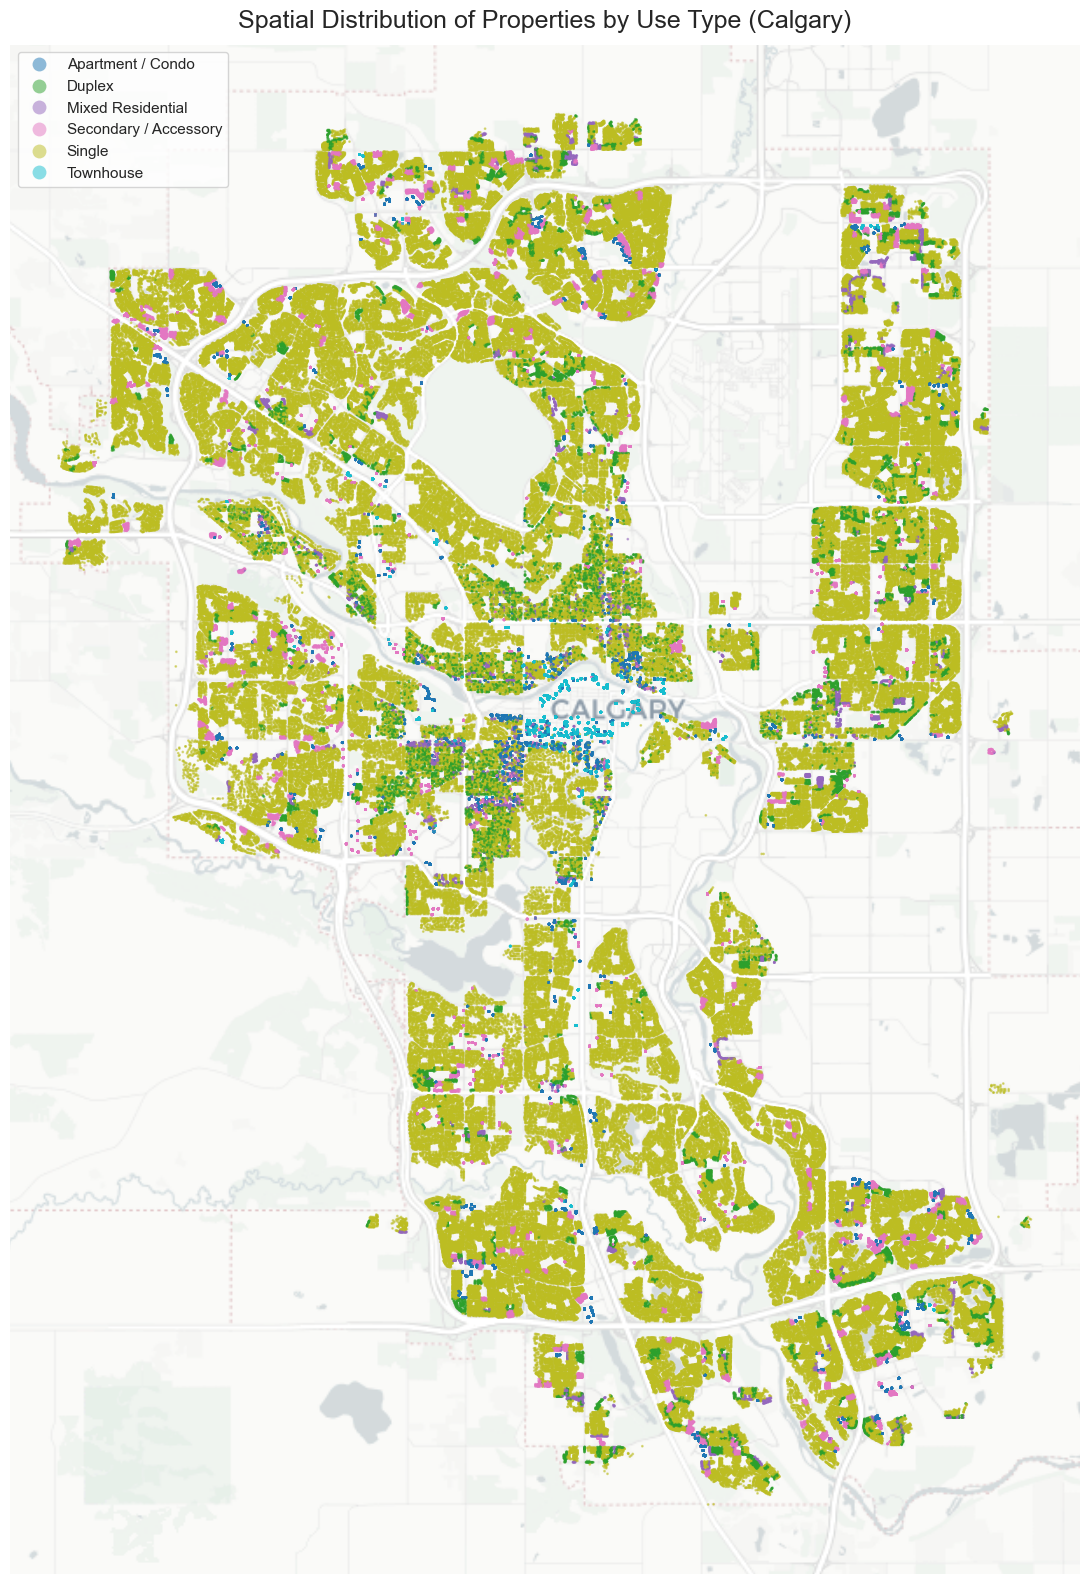

In [24]:
# Figure 1: Spatial Distribution of Properties by Use Type (Calgary)"
# Represents the types of housing properties that are distributed among the Calgary area.

fig, ax = plt.subplots(figsize=(16, 16))

gdf_3857.plot(
    ax=ax,
    column="PROPERTY_TYPE",
    categorical=True,
    legend=True,        
    markersize=1,
    alpha=0.5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    attribution=False
)

ax.set_title(
    "Spatial Distribution of Properties by Use Type (Calgary)",
    fontsize=18,
    pad=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


PROPERTY_TYPE
Single                   236919
Apartment / Condo         38016
Secondary / Accessory     37905
Duplex                    26582
Townhouse                 21699
Mixed Residential          9294
Name: count, dtype: int64

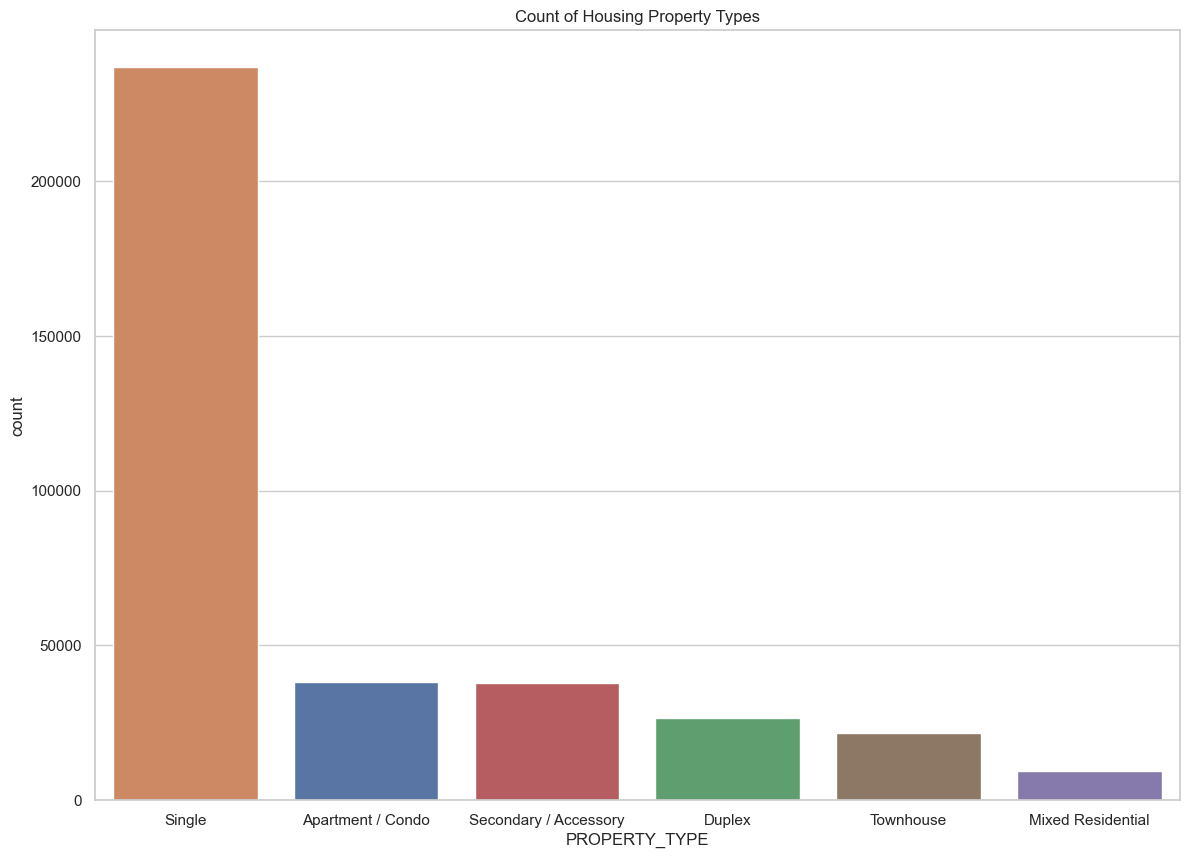

In [25]:
# Figure 2: Count of Housing Property Types 
# Counts all the housing property types.
sns.countplot(data=data, x='PROPERTY_TYPE', hue='PROPERTY_TYPE', order=data['PROPERTY_TYPE'].value_counts().index)
plt.title("Count of Housing Property Types")

data['PROPERTY_TYPE'].value_counts()

Text(0.5, 1.0, 'Distribution of Property Construction Years by Residential Use Code')

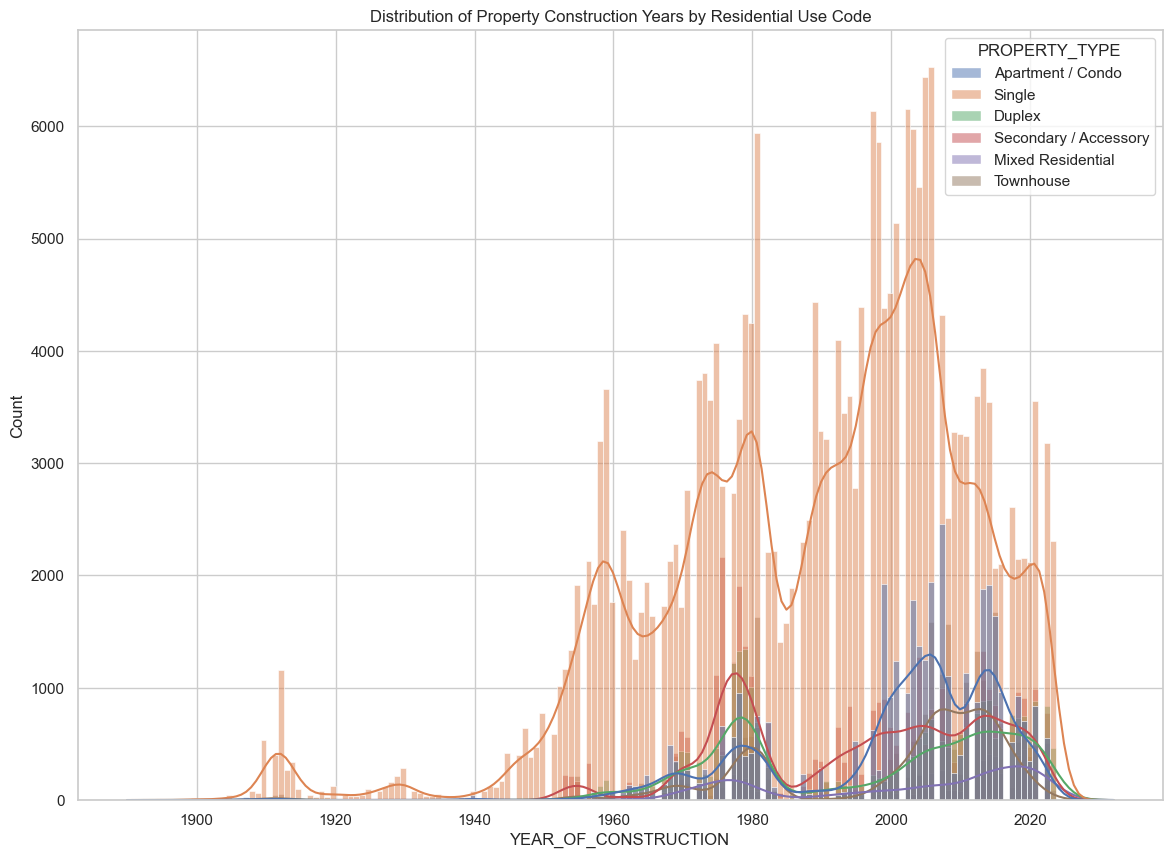

In [26]:
# Figure 3: Distribution of Property Construction Years by Residential Use Code
# Shows type of housing properties constructed by years in Calgary.

sns.histplot(data=data, x = 'YEAR_OF_CONSTRUCTION', hue='PROPERTY_TYPE', kde=True)
plt.title('Distribution of Property Construction Years by Residential Use Code')

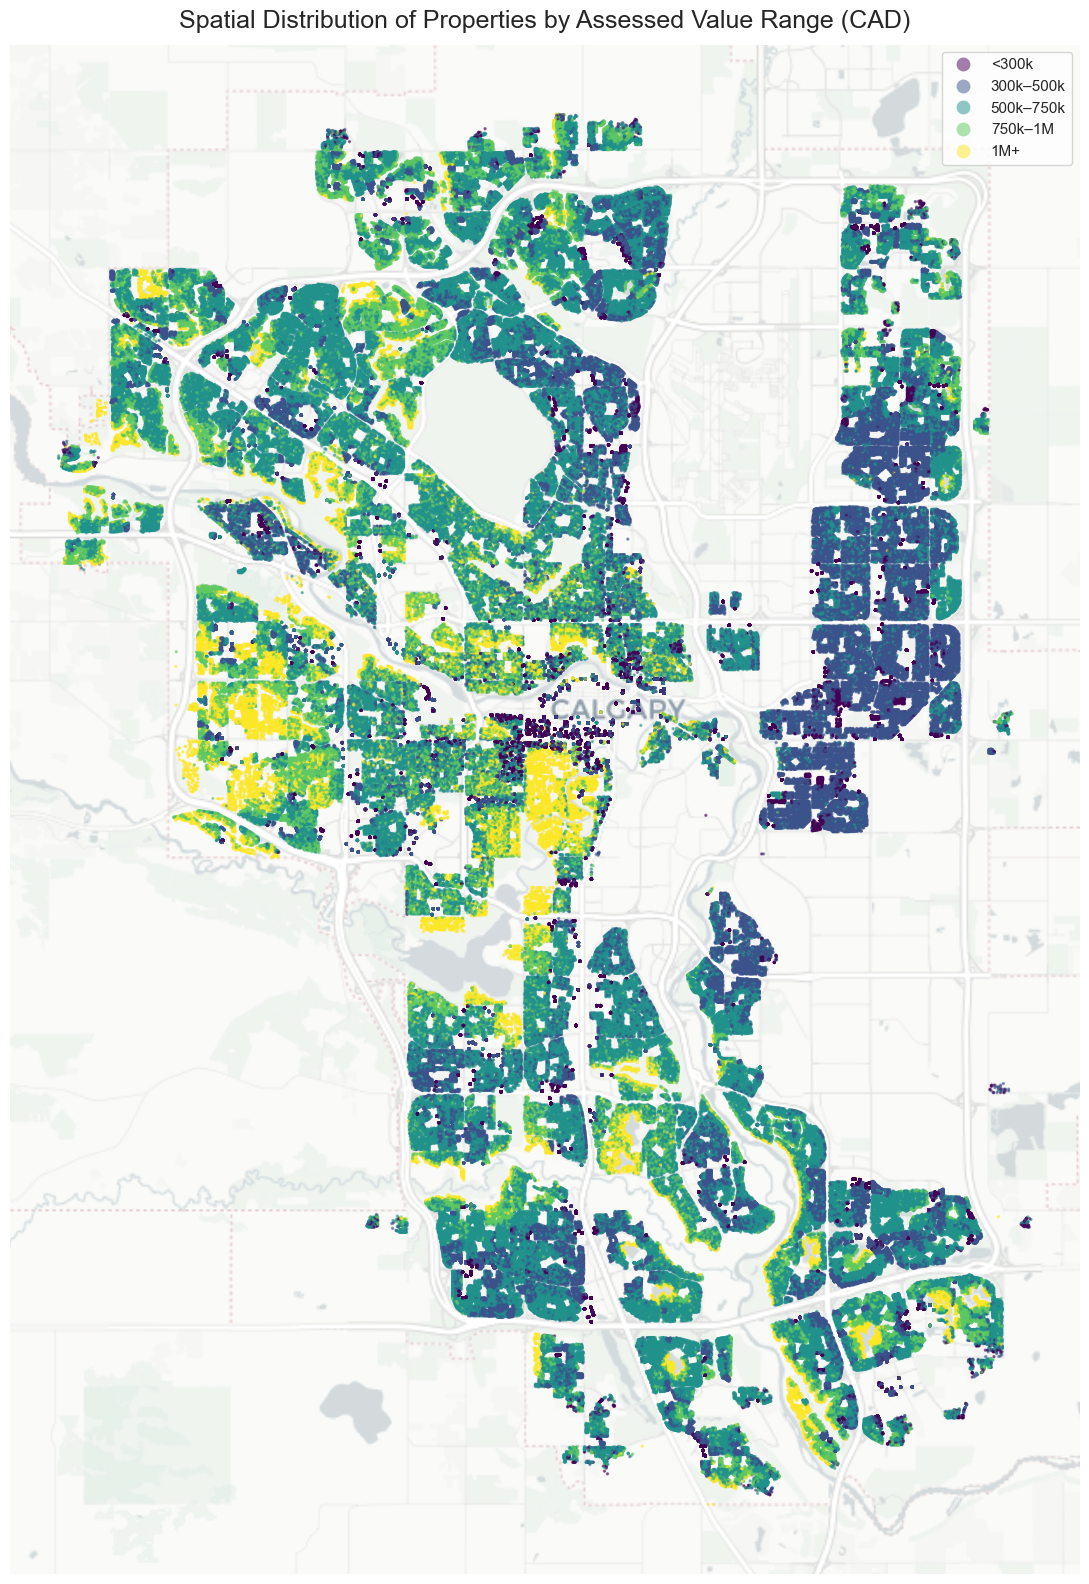

In [27]:
# Figure 4: Spatial Distribution of Properties by Assessed Value Range (CAD)
# Shows the assessed values of housing properties across Calgary.

fig, ax = plt.subplots(figsize=(16, 16))

gdf_3857.plot(
    ax=ax,
    column='ASSESSED_VALUE_RANGE',
    categorical=True,
    legend=True,        
    markersize=2,
    cmap='viridis',
    alpha=0.5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    attribution=False
)

ax.set_title(
    "Spatial Distribution of Properties by Assessed Value Range (CAD)",
    fontsize=18,
    pad=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

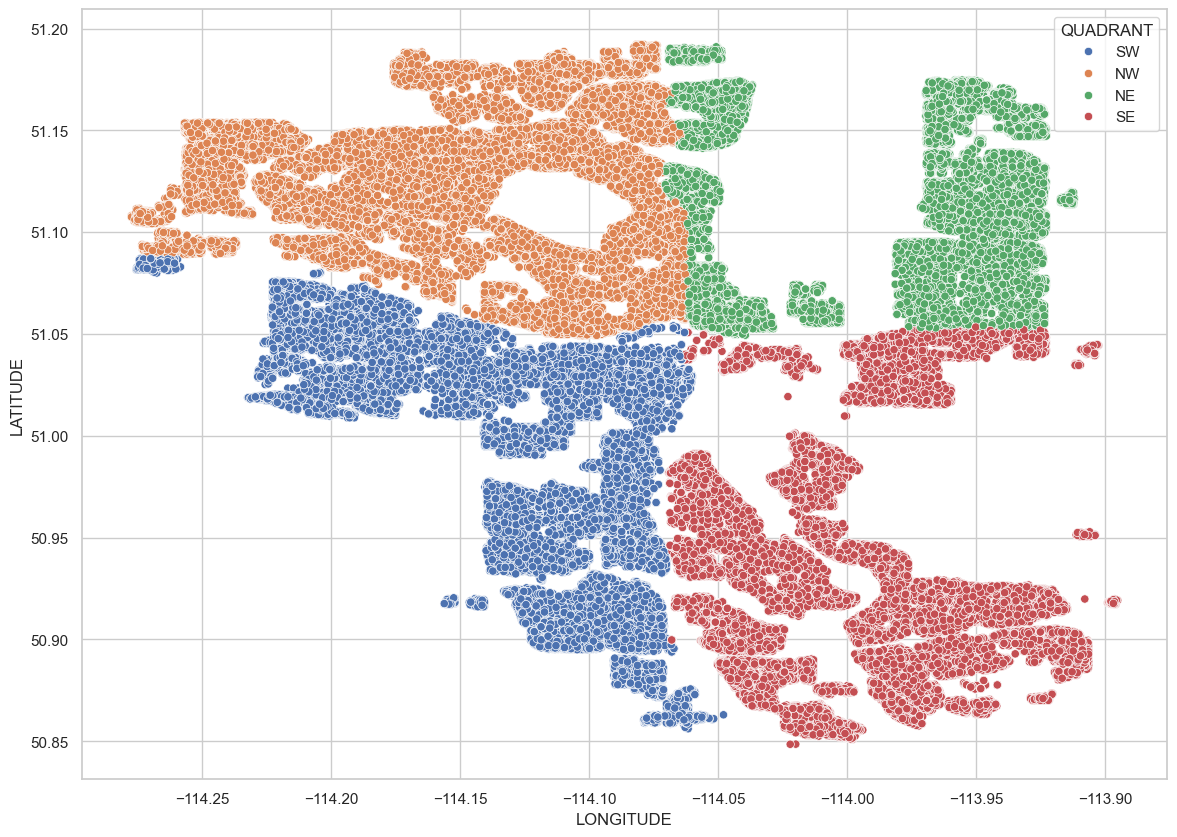

In [28]:
# Figure 5
# Sanity check to see if quadrants are properly representative according to their coordinates.
sns.scatterplot(data=data, x='LONGITUDE', y='LATITUDE', hue='QUADRANT')

QUADRANT
SW    105432
NW    102470
SE     93445
NE     69068
Name: count, dtype: int64

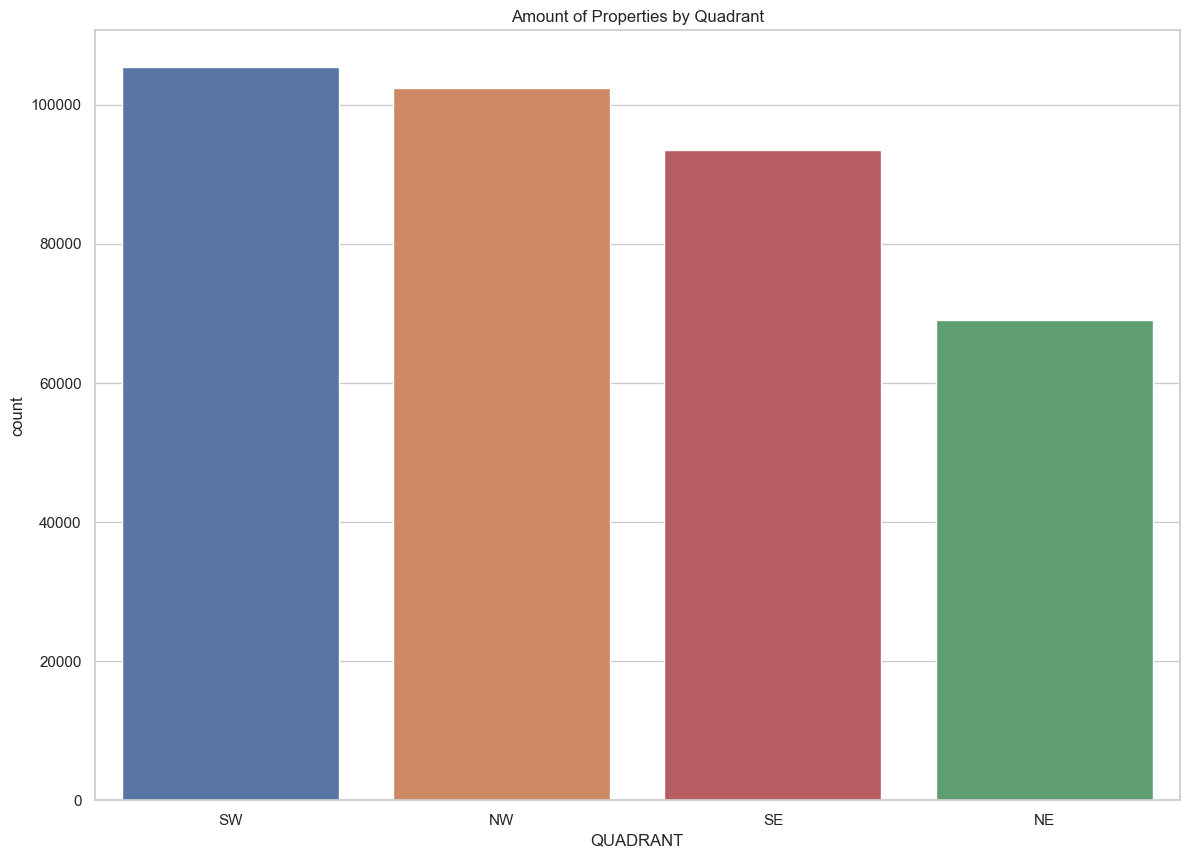

In [29]:
# Figure 6: Count of Housing Properties that Exist in each Quadrant
# Shows Housing properties per quadrant.
sns.countplot(data=data, x='QUADRANT', hue='QUADRANT', order=data['QUADRANT'].value_counts().index)
plt.title('Amount of Properties by Quadrant')

data['QUADRANT'].value_counts()

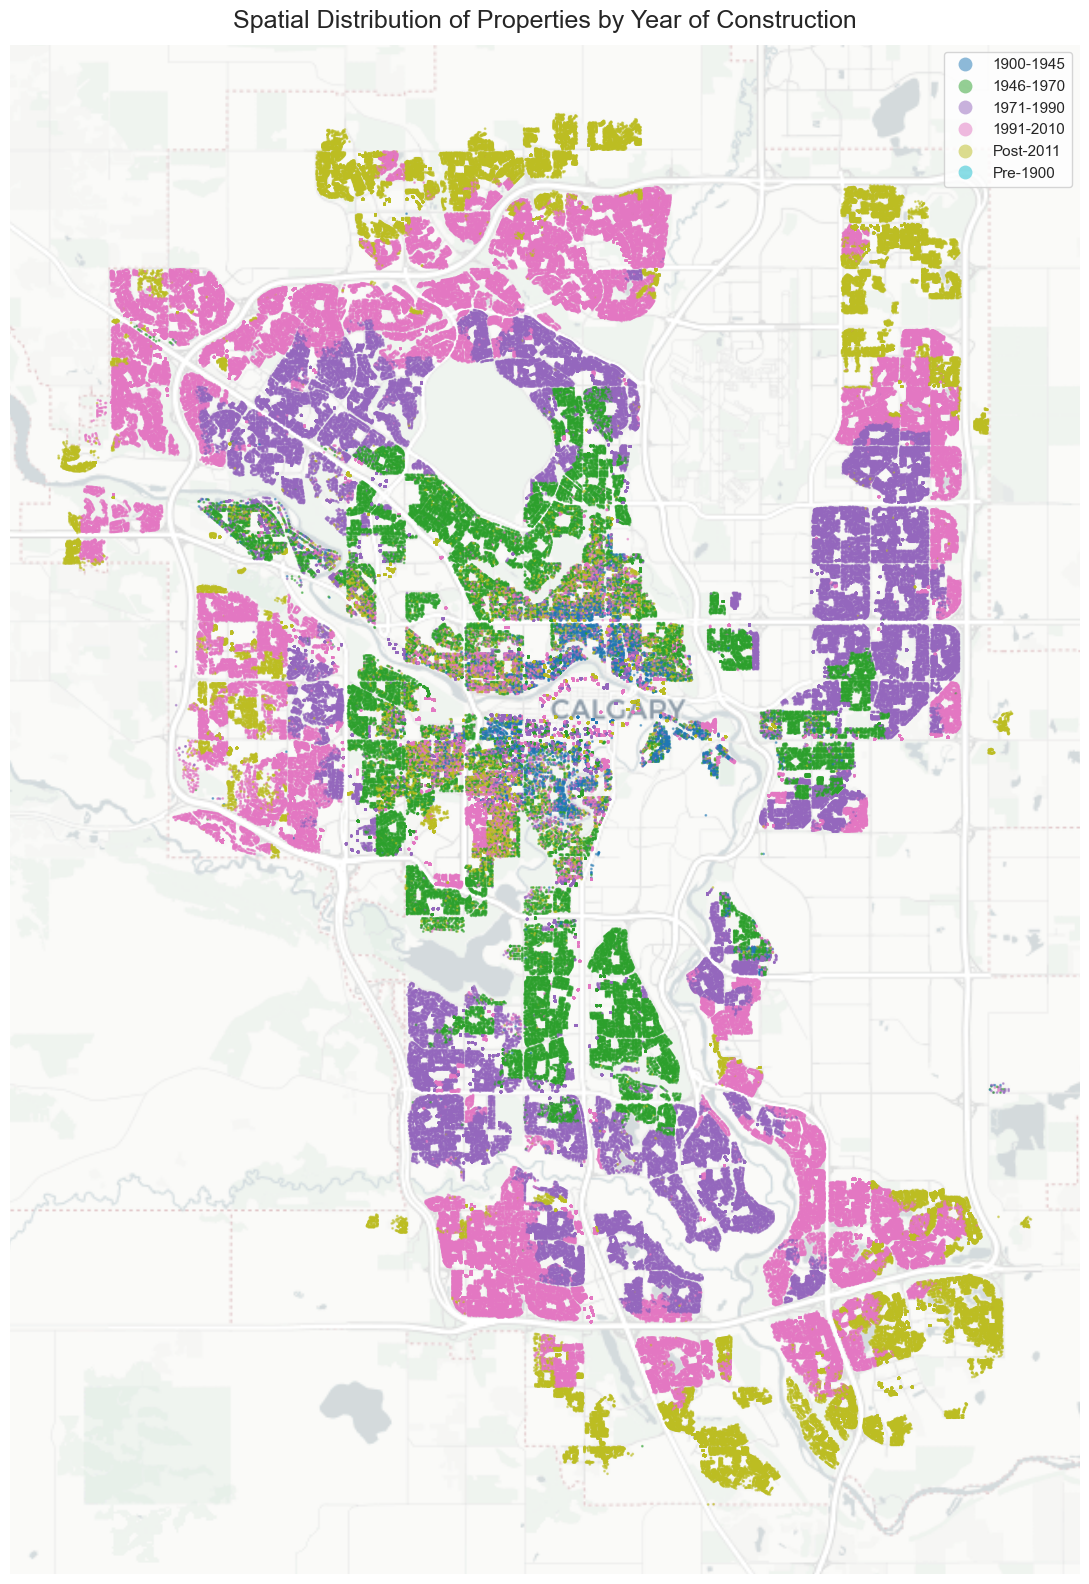

In [30]:
# Figure 7: Spatial Distribution of Properties by Year of Construction
# Shows development of housing properties by their year of construction in Calgary.

fig, ax = plt.subplots(figsize=(16, 16))

gdf_3857.plot(
    ax=ax,
    column="YEAR_OF_CONSTRUCTION_RANGE",
    categorical=True,
    legend=True,        
    markersize=1,
    alpha=0.5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    attribution=False
)

ax.set_title(
    "Spatial Distribution of Properties by Year of Construction",
    fontsize=18,
    pad=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Assessed Value of Housing Properties vs. Year of Construction')

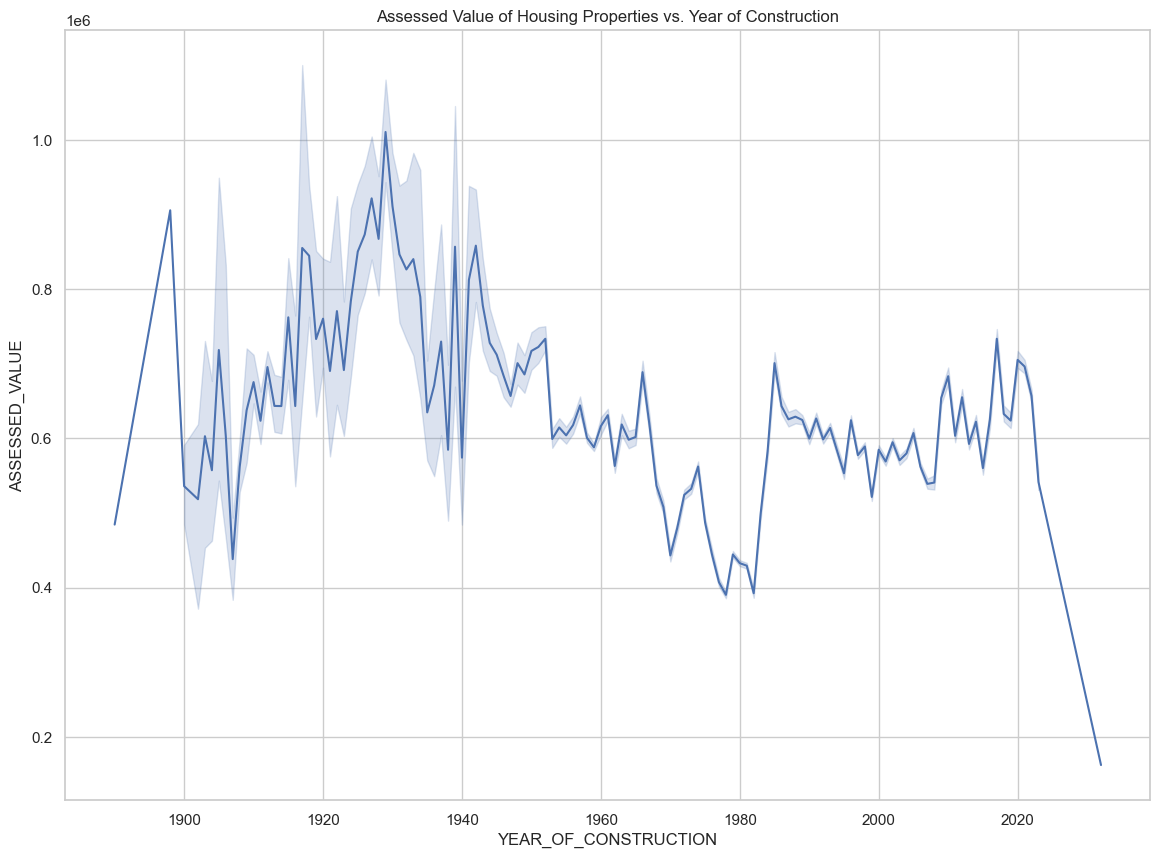

In [31]:
# Figure 8: Assessed Value of Housing Properties vs. Year of Construction
# Displays the various assessed values of housing properties across the years and their year of construction.

sns.lineplot(data=data, y='ASSESSED_VALUE', x='YEAR_OF_CONSTRUCTION')
plt.title('Assessed Value of Housing Properties vs. Year of Construction')

# Preparing and Training Data

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

# XGBoost Model

In [33]:
# Features
y = np.log1p(data["ASSESSED_VALUE"])
data["LOG_LAND_SIZE"] = np.log1p(data['LAND_SIZE_SM'])
X = data[["LOG_LAND_SIZE", "YEAR_OF_CONSTRUCTION_RANGE", "QUADRANT", "PROPERTY_TYPE",]]

# Train, Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["QUADRANT", "PROPERTY_TYPE", "YEAR_OF_CONSTRUCTION_RANGE"]
        ),
        (
            "num",
            "passthrough",
            ["LOG_LAND_SIZE"]
        )
    ]
)


model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

y_pred_log = pipeline.predict(X_test)

# Convert back to dollar scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("MAE ($):", mean_absolute_error(y_test_actual, y_pred_actual))
print("R²:", r2_score(y_test_actual, y_pred_actual))



MAE ($): 97288.44852416377
R²: 0.6562046346250205


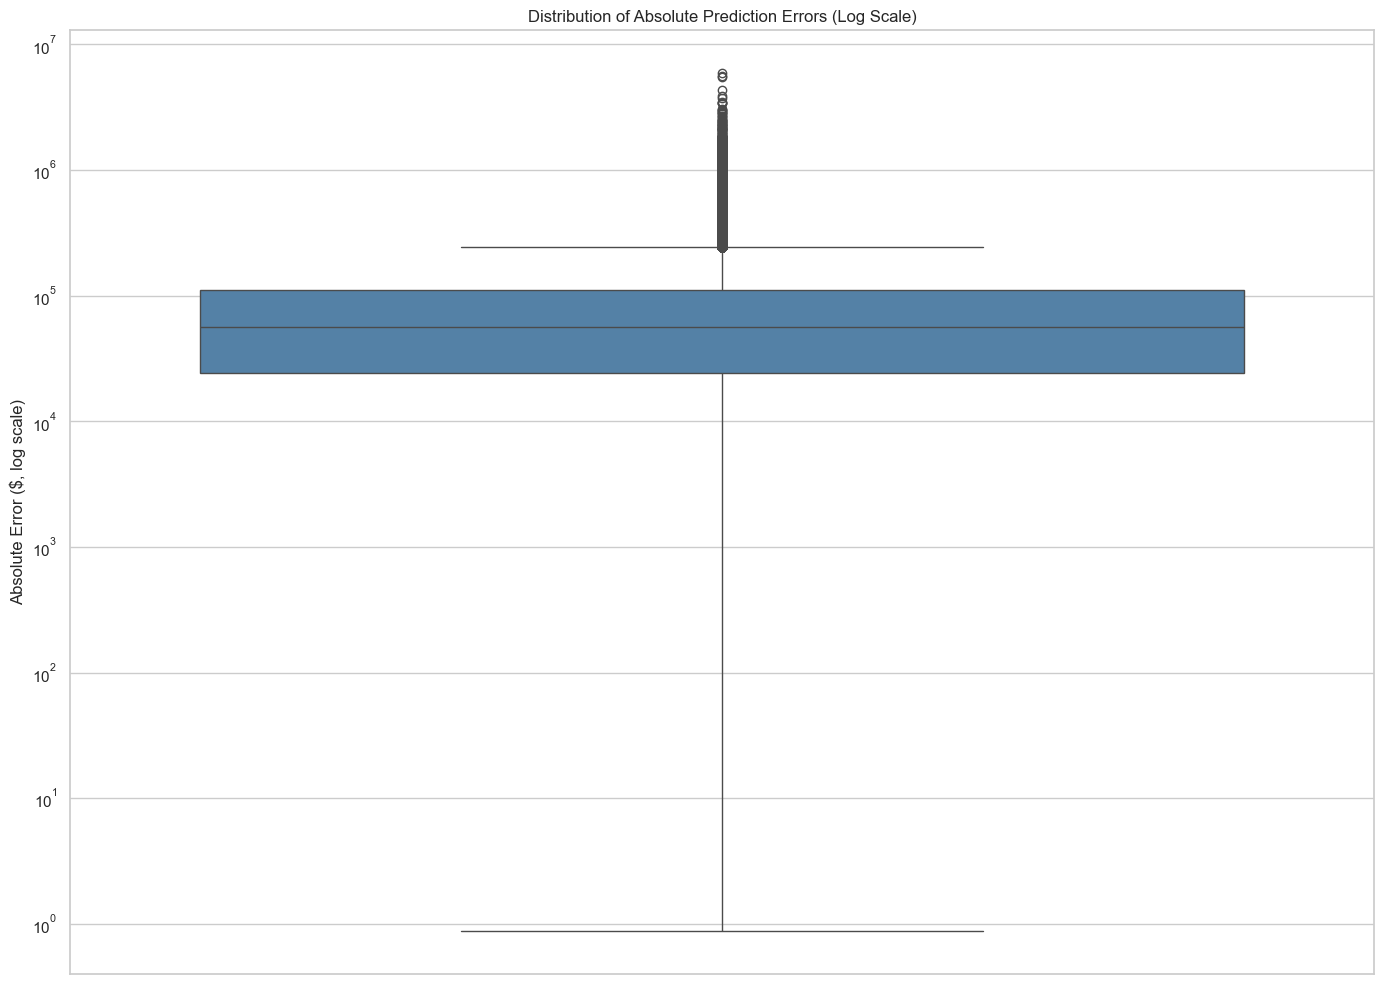

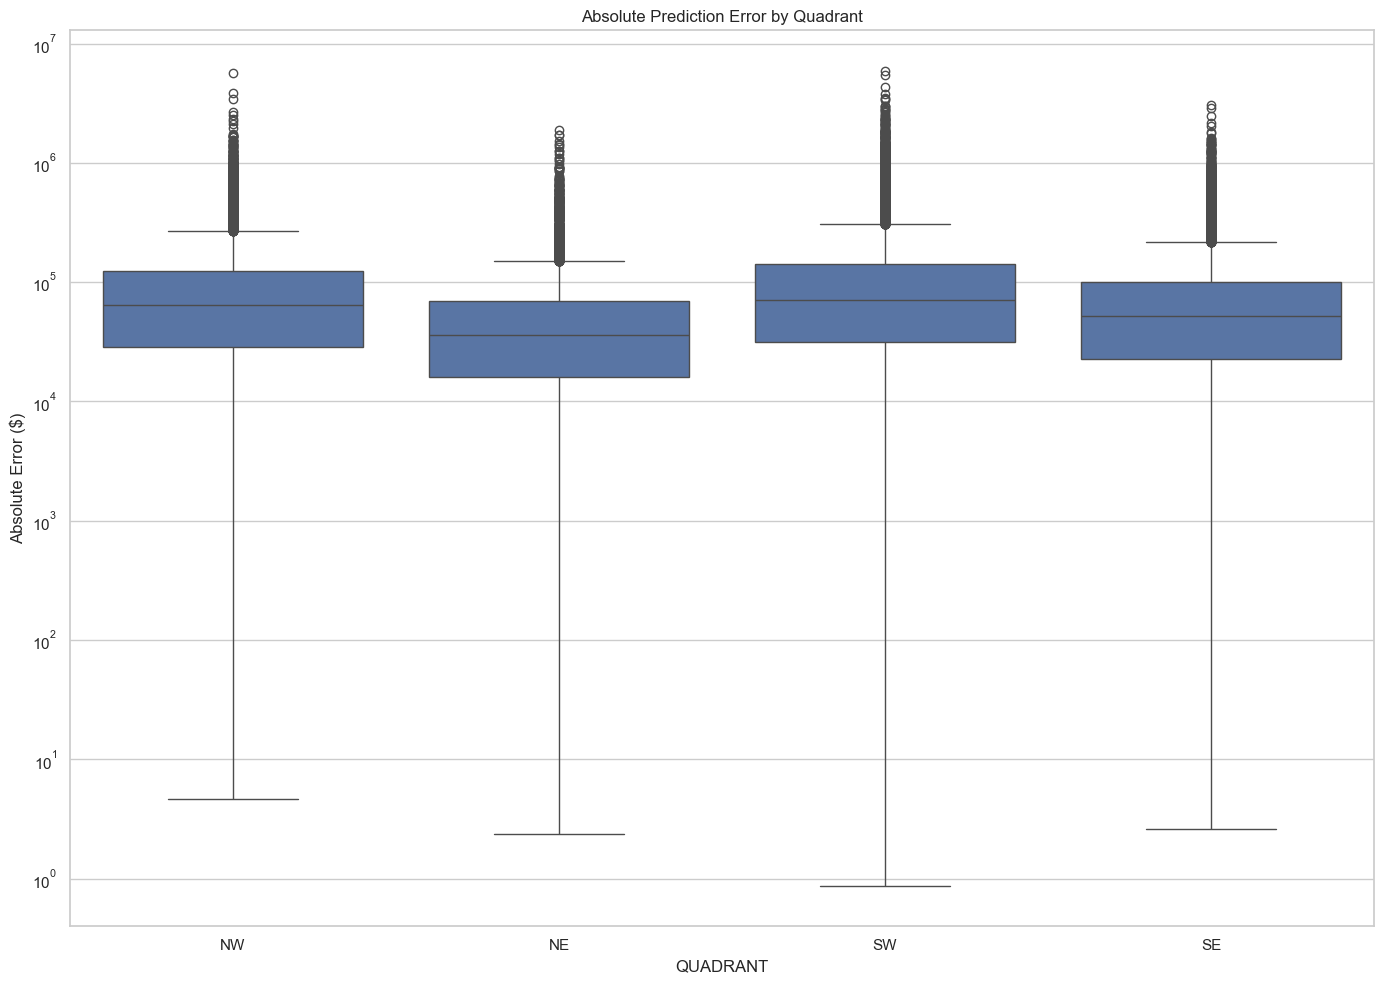

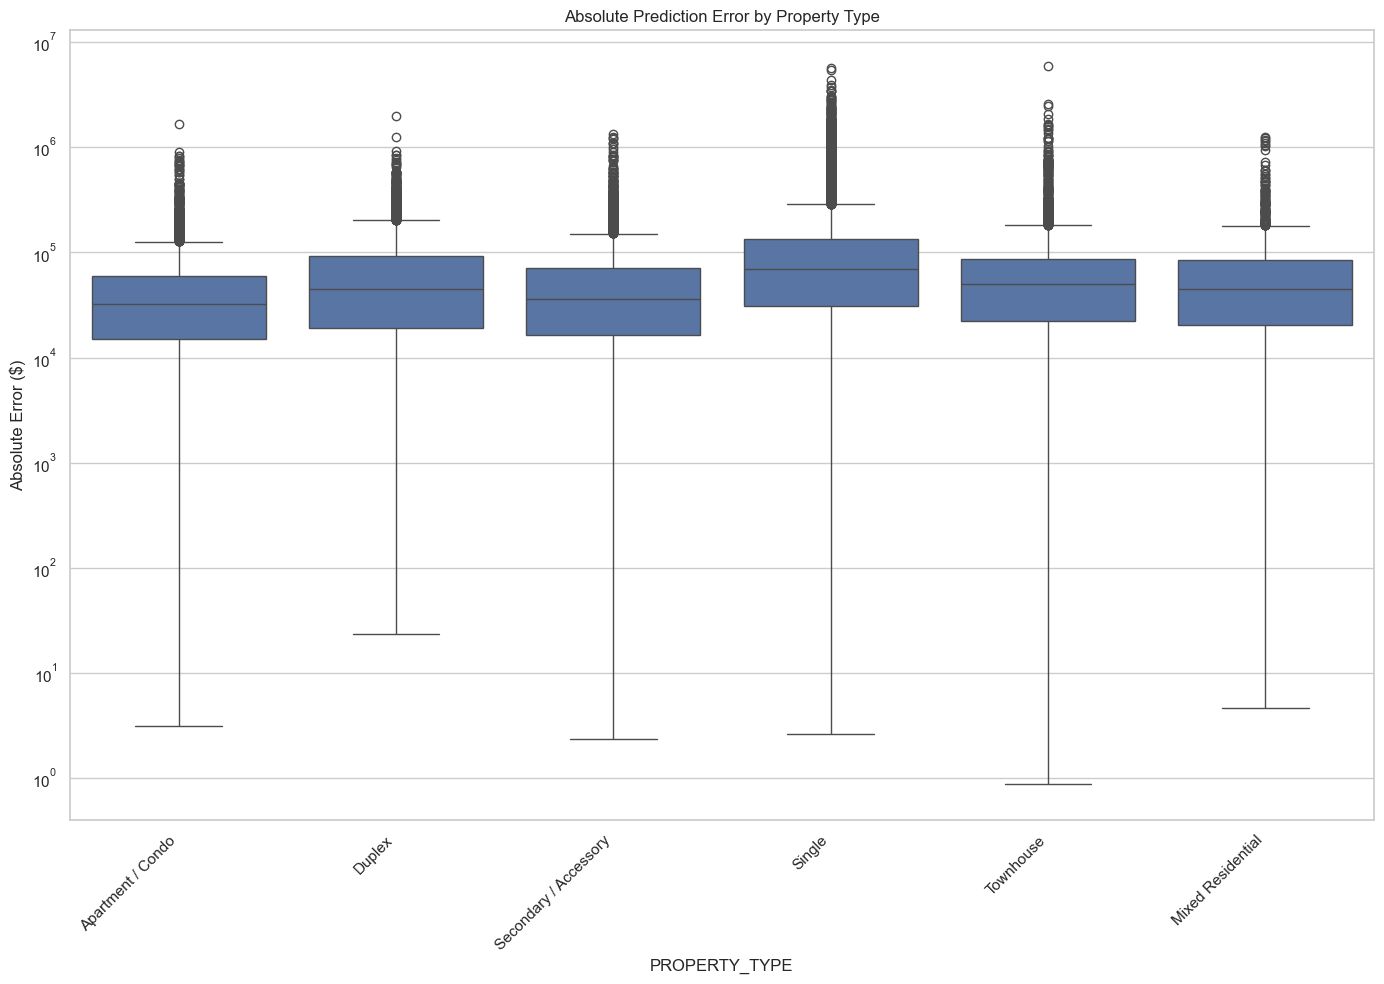

In [34]:
# Result Diagnostics
error_df = pd.DataFrame({
    "Actual Price": y_test_actual,
    "Predicted Price": y_pred_actual
})

error_df["Absolute Error ($)"] = (
    error_df["Actual Price"] - error_df["Predicted Price"]
).abs()

# Distribution of Absolute Prediction Errors
sns.boxplot(
    data=error_df,
    y="Absolute Error ($)",
    color="steelblue"
)

plt.yscale("log")
plt.title("Distribution of Absolute Prediction Errors (Log Scale)")
plt.ylabel("Absolute Error ($, log scale)")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Quadrant
sns.boxplot(
    data=error_df.join(X_test["QUADRANT"]),
    x="QUADRANT",
    y="Absolute Error ($)",
    order=["NW", "NE", "SW", "SE"]
)

plt.yscale("log")
plt.title("Absolute Prediction Error by Quadrant")
plt.tight_layout()
plt.show()

# Property Type
sns.boxplot(
    data=error_df.join(X_test["PROPERTY_TYPE"]),
    x="PROPERTY_TYPE",
    y="Absolute Error ($)"
)

plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.title("Absolute Prediction Error by Property Type")
plt.tight_layout()
plt.show()


C:\Users\Zaine\AppData\Local\Temp\ipykernel_8436\1257617383.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


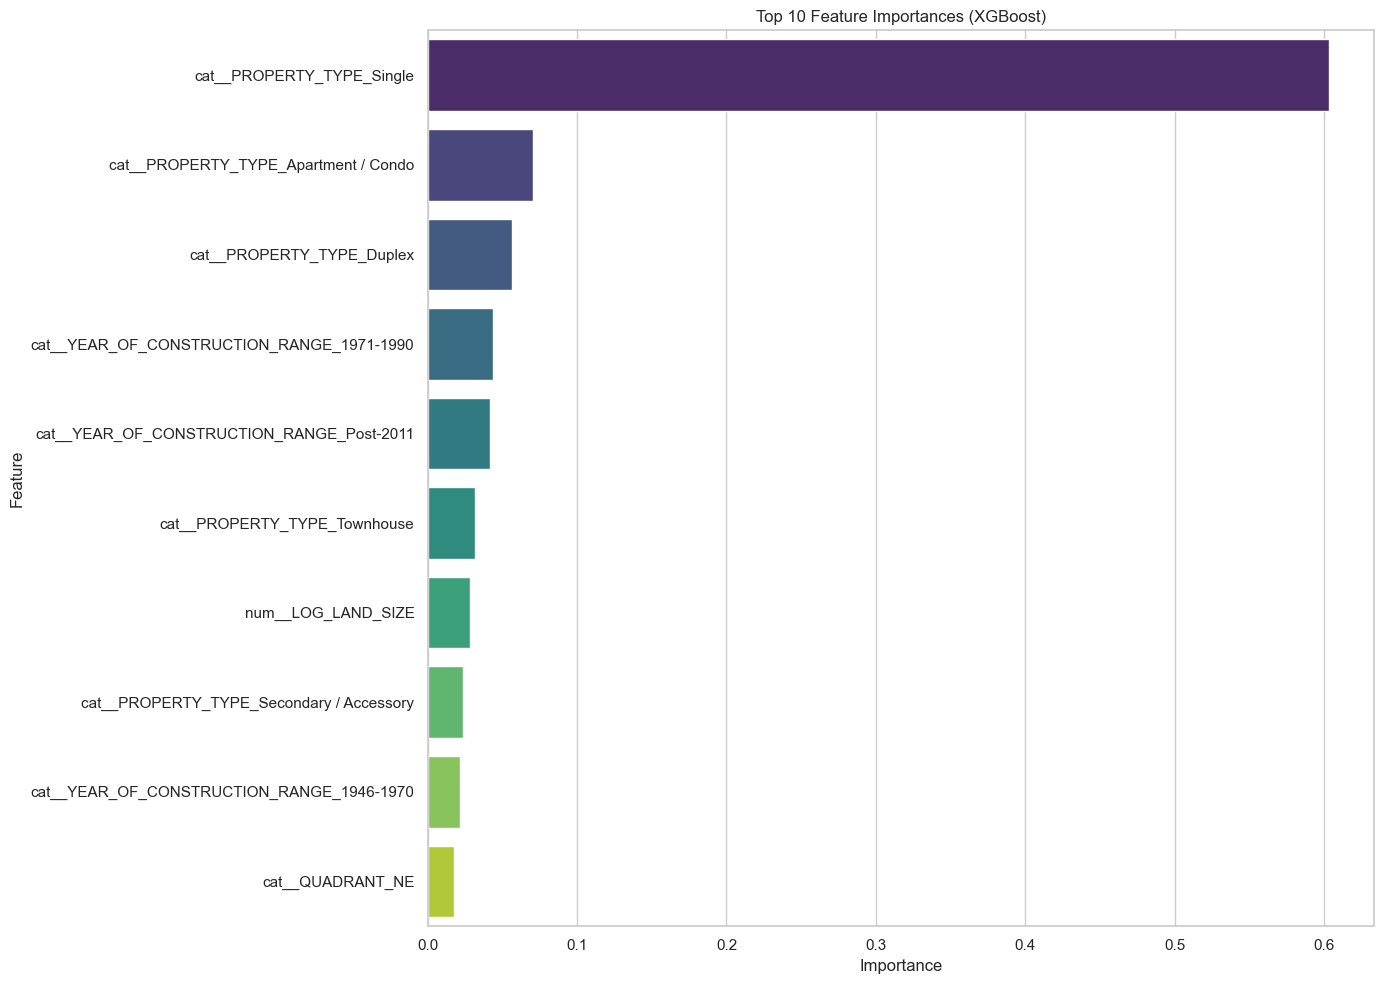

In [35]:
# I wanted to see which features the model used the most.
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocess"]

importances = model.feature_importances_

feature_names = preprocessor.get_feature_names_out()

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(
    data=fi.head(10),
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [37]:
import joblib
joblib.dump(pipeline, "xgb_housing_pipeline.joblib")


['xgb_housing_pipeline.joblib']